# 04 — The RF chain

Notebook 03 left us with an open-circuit voltage $V_{\rm oc}$ at the antenna
terminals. Between there and the digitiser sits a cascade of two-port networks:
a matching network, a low-noise amplifier, two baluns, a coaxial cable, and a
variable-gain amplifier with a band-pass filter.

Each stage ships as measured **S-parameters**. GRANDlib converts each to an
ABCD matrix, multiplies the matrices in order, and terminates the result in the
ADC load impedance. The product is one complex number per frequency and arm,

$$H(\nu) = \frac{V_{\rm out}(\nu)}{V_{\rm oc}(\nu)}$$

This notebook builds that cascade stage by stage — and ends by showing a bug
that a plot makes obvious and a code review does not.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from grand.sim.detector.rf_chain import RFChain

# The GRAND band, in MHz and on a 1 MHz grid.  Everything in rf_chain.py takes
# and returns MHz -- unlike the antenna model of notebook 03, which stores Hz.
# Mixing the two up is the most common mistake in this module.
freqs_mhz = np.arange(30.0, 251.0)

# 20 dB is the GRANDProto300 default.  Section 5 shows that this argument is
# currently ignored, so every chain built here is a 20 dB chain regardless.
chain = RFChain(vga_gain=20)

# Construction only gathers the stages; this is what evaluates them.  It must be
# called before get_tf(), and it stores its results on the instance rather than
# returning them.
chain.compute_for_freqs(freqs_mhz)

tf = chain.get_tf()          # (3 arms, n_freq), complex
print("transfer function:", tf.shape, tf.dtype)

transfer function: (3, 221) complex64


## 1. The stages

`RFChain` is a facade. Each stage is a `GenericProcessingDU` subclass that
loads its own data file and exposes `s11`, `s21` and an `ABCD_matrix` of shape
`(2, 2, 3, n_freq)` — two by two for the network, then one per arm and
frequency.

In [2]:
# The attribute names on RFChain, in the order the signal meets them
# physically.  Section 3 shows that this is *not* the order they are multiplied
# in, which is worth knowing before reading the source.
stages = ['matcnet', 'lna', 'balun1', 'cable', 'vgaf', 'balun2']

for name in stages:
    s = getattr(chain, name)
    print("%-9s %-22s ABCD %s" % (name, type(s).__name__, s.ABCD_matrix.shape))

matcnet   MatchingNetwork        ABCD (2, 2, 3, 221)
lna       LowNoiseAmplifier      ABCD (2, 2, 3, 221)
balun1    BalunAfterLNA          ABCD (2, 2, 3, 221)
cable     Cable                  ABCD (2, 2, 3, 221)
vgaf      VGAFilter              ABCD (2, 2, 3, 221)
balun2    BalunBeforeADC         ABCD (2, 2, 3, 221)


## 2. What each stage does on its own

$|S_{21}|$ in dB is the forward gain of a stage measured into a matched load.
Plotting them together shows the division of labour: the LNA supplies the gain,
the cable takes some back, and the VGA/filter stage defines the band edges.

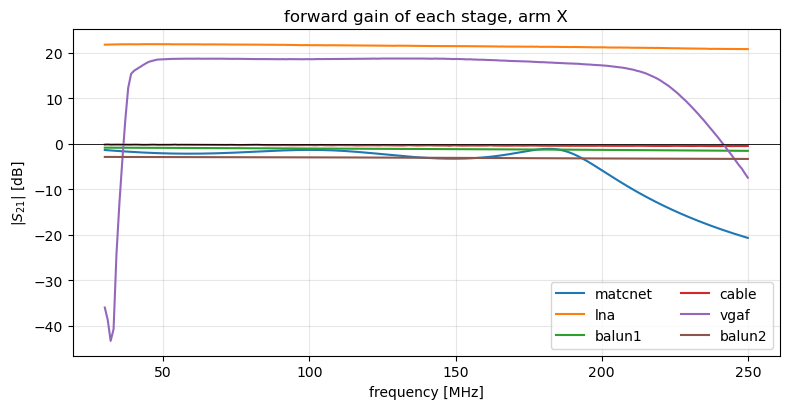

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for name in stages:
    # s21 is stored per arm; arm 0 is representative and keeps the figure legible.
    s21 = getattr(chain, name).s21[0]
    # 20 log10 because S-parameters are amplitude ratios, not power ratios.  The
    # 1e-30 floor keeps log10 finite where a stage has an exact zero.
    ax.plot(freqs_mhz, 20 * np.log10(np.abs(s21) + 1e-30), label=name)

ax.axhline(0, color='k', lw=.6)       # unity gain, for reference
ax.set_xlabel('frequency [MHz]')
ax.set_ylabel(r'$|S_{21}|$ [dB]')
ax.set_title('forward gain of each stage, arm X')
ax.grid(alpha=.3)
ax.legend(ncol=2)
fig.tight_layout()

## 3. Why ABCD and not just S

S-parameters are defined against a reference impedance and do not compose by
multiplication. ABCD (chain) matrices do:

$$\begin{pmatrix} A & B \\ C & D \end{pmatrix}_{\rm total}
 = \prod_{k} \begin{pmatrix} A & B \\ C & D \end{pmatrix}_{k}$$

so the cascade is a matrix product over stages. `rf_chain.s2abcd` does the
S-to-ABCD conversion and `rf_chain.matmul` the product. The antenna impedance
$Z_{\rm ant}$ enters at the input and the ADC load $Z_{\rm load}$ at the
output, which is why a stage's isolated $|S_{21}|$ above does **not** simply
add up to the total below.

The order the code actually uses is

```
balun1 . matcnet . lna . cable . vgaf . balun2
```

Worth flagging for anyone reading the source: the first factor is the class
named `BalunAfterLNA`, and it is applied *before* the matching network and the
LNA. Either the name or the order is misleading; which one has not been
established here. The cell below reproduces the product by hand, which is how
that order was determined.

In [4]:
from grand.sim.detector.rf_chain import matmul

# The order compute_for_freqs() multiplies in -- not the physical order above.
order = ['balun1', 'matcnet', 'lna', 'cable', 'vgaf', 'balun2']

# matmul() here is rf_chain's own, which contracts the leading 2x2 and broadcasts
# over the trailing (arm, frequency) axes.  It is not np.matmul.
M = getattr(chain, order[0]).ABCD_matrix
for name in order[1:]:
    M = matmul(M, getattr(chain, name).ABCD_matrix)

# Index [0, 0, 0, 70] is the A element, arm X, at 30 + 70 = 100 MHz.
print("hand-cascaded  A(100 MHz), arm X:", M[0, 0, 0, 70])
print("chain.total_ABCD_matrix         :", chain.total_ABCD_matrix[0, 0, 0, 70])
print("agree:", np.allclose(M, chain.total_ABCD_matrix, rtol=1e-4))

hand-cascaded  A(100 MHz), arm X: (0.0030245367+0.002649235j)
chain.total_ABCD_matrix         : (0.0030245367+0.002649235j)
agree: True


## 4. The total transfer function

This is Fig. 8 of [arXiv:2408.10926](https://arxiv.org/abs/2408.10926): the
factor by which the chain multiplies $V_{\rm oc}$.

peak gain per arm: [94.8 93.5 69. ]
in dB            : [39.5 39.4 36.8]


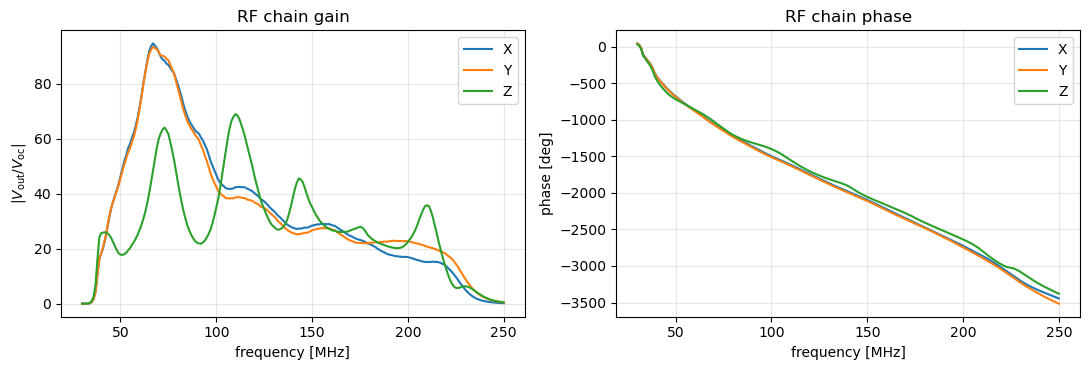

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for i, arm in enumerate('XYZ'):
    ax[0].plot(freqs_mhz, np.abs(tf[i]), label=arm)
    # Unwrapped so the delay shows as a straight line rather than a sawtooth.
    ax[1].plot(freqs_mhz, np.degrees(np.unwrap(np.angle(tf[i]))), label=arm)

ax[0].set_ylabel(r'$|V_{\rm out}/V_{\rm oc}|$')
ax[1].set_ylabel('phase [deg]')
ax[0].set_title('RF chain gain')
ax[1].set_title('RF chain phase')
for a in ax:
    a.set_xlabel('frequency [MHz]')
    a.grid(alpha=.3)
    a.legend()
fig.tight_layout()

gain_db = 20 * np.log10(np.abs(tf))
print("peak gain per arm:", np.round(np.abs(tf).max(axis=1), 1))
print("in dB            :", np.round(gain_db.max(axis=1), 1))

Two features worth noting. The band edges near 30 and 250 MHz come from the
filter, not from the antenna — the antenna of notebook 03 is tabulated over
exactly this range, so the two are matched by construction. And the phase is
smooth and steeply sloped: the chain delays the pulse by a fixed amount, which
the reconstruction has to know about.

## 5. A bug you can see

`RFChain` takes a `vga_gain` argument. S-parameters are shipped for −5, 0, 5
and 20 dB, so four different chains should give four different curves separated
by 25 dB end to end.

They do not.

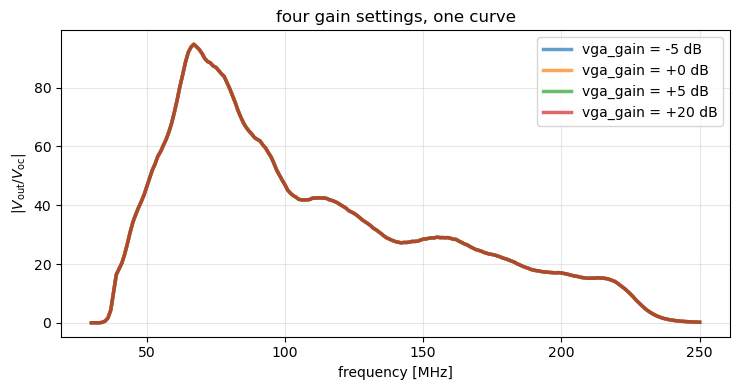

In [6]:
settings = [-5, 0, 5, 20]
curves = {}
for g in settings:
    # A fresh chain per setting, so nothing is carried over between them.
    c = RFChain(vga_gain=g)
    c.compute_for_freqs(freqs_mhz)
    curves[g] = np.abs(c.get_tf()[0])       # arm X

fig, ax = plt.subplots(figsize=(7.5, 4))
for g, y in curves.items():
    # Thick and semi-transparent, so four distinct curves would be visible as
    # four bands.  They are not, because there is only one curve here.
    ax.plot(freqs_mhz, y, lw=2.5, alpha=.7, label='vga_gain = %+d dB' % g)

ax.set_xlabel('frequency [MHz]')
ax.set_ylabel(r'$|V_{\rm out}/V_{\rm oc}|$')
ax.set_title('four gain settings, one curve')
ax.grid(alpha=.3)
ax.legend()
fig.tight_layout()

In [7]:
# The figure could be hiding four curves that happen to overlap on this scale,
# so check the difference directly rather than trusting the eye.
ref = curves[20]
for g, y in curves.items():
    print("vga_gain = %+3d dB : max relative difference from 20 dB = %.3g"
          % (g, np.max(np.abs(y - ref) / ref)))

vga_gain =  -5 dB : max relative difference from 20 dB = 0
vga_gain =  +0 dB : max relative difference from 20 dB = 0
vga_gain =  +5 dB : max relative difference from 20 dB = 0
vga_gain = +20 dB : max relative difference from 20 dB = 0


All four are bit-identical. The gain argument is accepted, stored, and never
used to select the data file — `VGAFilter._set_name_data_file` ignores it and
loads the 20 dB table regardless.

The consequence is not cosmetic. Any study that varies the VGA setting — a
dynamic-range scan, a saturation study, a comparison against a run taken at a
different gain — silently produces the 20 dB answer. That is worse than an
error, because the output looks plausible.

This is pinned by an expected-to-fail test in
`tests/sim/test_rf_chain_physics.py`, so the day the loader is fixed the suite
will say so:

```python
@pytest.mark.xfail(reason='vga_gain is currently ignored: ...')
def test_vga_gain_changes_the_transfer_function():
    low, high = RFChain(vga_gain=0), RFChain(vga_gain=20)
    ...
```

The fix is a one-line change in the file-name builder. It is left undone
deliberately: nobody has confirmed which of the shipped tables corresponds to
which hardware configuration, and guessing would replace a visible bug with an
invisible one.

## Where next

- [03 — The antenna response](03_antenna_response.ipynb) — where $V_{\rm oc}$ came from
- [05 — Galactic noise](05_galactic_noise.ipynb) — what is added alongside it
- [06 — From electric field to ADC counts](06_efield_to_adc.ipynb) — the whole chain at once